In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df_main = pd.read_csv(r'FINAL_BINARY_DATASET.csv')

In [3]:
target_mapping = {'No_Disease':0,
                  'Disease':1}
df_main['Target'] = df_main['Target'].map(target_mapping)


Classification Report: 
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       700
           1       0.86      0.75      0.80       606

    accuracy                           0.83      1306
   macro avg       0.83      0.82      0.82      1306
weighted avg       0.83      0.83      0.83      1306



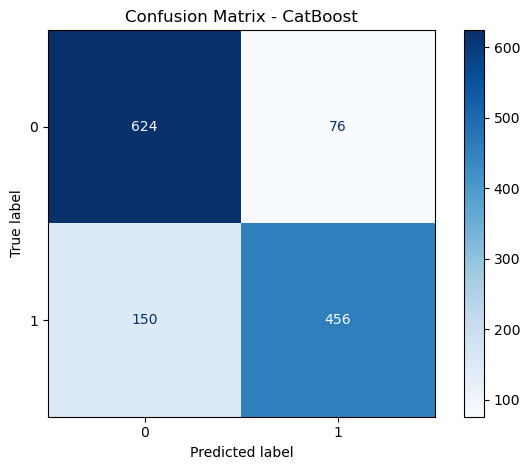

In [5]:
from collections import Counter
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


CAT_boost_selected_features = [
    "Pus cells in urine", "Age of the patient", "Body Mass Index (BMI)",
    "Sodium level (mEq/L)", "Estimated Glomerular Filtration Rate (eGFR)",
    "Urine protein-to-creatinine ratio", "Duration of diabetes mellitus (years)",
    "C-reactive protein (CRP) level", "Sugar in urine", "Cystatin C level",
    "Interleukin-6 (IL-6) level", "White blood cell count (cells/cumm)",
    "Cholesterol level", "Serum phosphate level", "Serum albumin level",
    "Family history of chronic kidney disease", "Bacteria in urine", "Appetite (good/poor)"
]

TARGET_COLUMN = "Target"


df_fe = df_main.copy()


df_fe["IL6_albumin_ratio"] = df_fe["Interleukin-6 (IL-6) level"] / df_fe["Serum albumin level"]
df_fe["protein_eGFR_ratio"] = df_fe["Urine protein-to-creatinine ratio"] / df_fe["Estimated Glomerular Filtration Rate (eGFR)"]
df_fe["CRP_WBC_ratio"] = df_fe["C-reactive protein (CRP) level"] / df_fe["White blood cell count (cells/cumm)"]


df_fe["log_Cystatin_C"] = np.log1p(df_fe["Cystatin C level"])
df_fe["sqrt_Cholesterol"] = np.sqrt(df_fe["Cholesterol level"])


df_fe["Age_group"] = pd.cut(df_fe["Age of the patient"], bins=[0, 30, 50, 70, 100], labels=["<30", "30-50", "50-70", "70+"])
df_fe["BMI_category"] = pd.cut(df_fe["Body Mass Index (BMI)"], bins=[0, 18.5, 25, 30, np.inf], labels=["Underweight", "Normal", "Overweight", "Obese"])


appetite_counts = df_fe["Appetite (good/poor)"].value_counts()
df_fe["Appetite_encoded"] = df_fe["Appetite (good/poor)"].map(appetite_counts)


for col in CAT_boost_selected_features:
    df_fe[col + "_missing_flag"] = df_fe[col].isnull().astype(int)


categorical_cols = [
    "Age_group", "BMI_category", "Appetite (good/poor)",
    "Family history of chronic kidney disease", "Pus cells in urine",
    "Sugar in urine", "Bacteria in urine"
]


X = df_fe.drop(columns=[TARGET_COLUMN])
y = df_fe[TARGET_COLUMN]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


class_counts = Counter(y_train)
total = sum(class_counts.values())
weights = {cls: total / count for cls, count in class_counts.items()}


model = CatBoostClassifier(
    verbose=False,
    scale_pos_weight=1.2,
    iterations=1000,
    depth=6,
    learning_rate=0.03,
    l2_leaf_reg=4,
    random_strength=1,
    bagging_temperature=0.5,
    border_count=128,
    early_stopping_rounds=100
)


model.fit(
    X_train, y_train,
    cat_features=categorical_cols,
    eval_set=(X_test, y_test)
)


preds = model.predict(X_test)
print("\nClassification Report: ")
print(classification_report(y_test, preds))

cm = confusion_matrix(y_test, preds)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.title("Confusion Matrix - CatBoost")
plt.tight_layout()
plt.show()




In [7]:
df_final = df_main[CAT_boost_selected_features + ['Target']]

In [8]:
df_final.shape

(6528, 19)

Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.70      0.64       700
           1       0.57      0.45      0.50       606

    accuracy                           0.58      1306
   macro avg       0.58      0.58      0.57      1306
weighted avg       0.58      0.58      0.58      1306

Confusion Matrix:
 [[490 210]
 [332 274]]


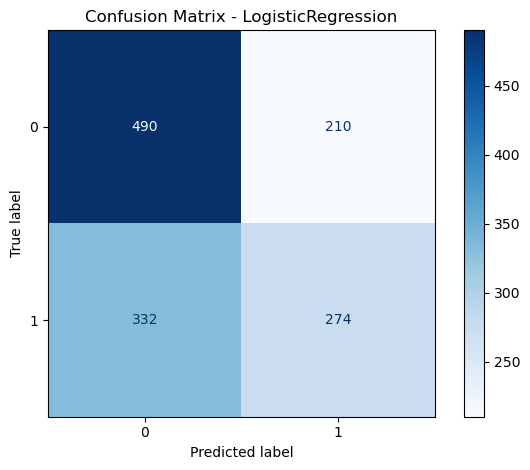

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix


X = df_final.drop('Target', axis=1)
y = df_final['Target']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)


logreg = LogisticRegression(random_state=42)
logreg.fit(X_train, y_train)


y_pred = logreg.predict(X_test)


print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.title("Confusion Matrix - LogisticRegression")
plt.tight_layout()
plt.show()


Best Parameters: {'metric': 'manhattan', 'n_neighbors': 26, 'weights': 'uniform'}
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.56      0.61       700
           1       0.58      0.70      0.64       606

    accuracy                           0.63      1306
   macro avg       0.63      0.63      0.63      1306
weighted avg       0.64      0.63      0.62      1306

Confusion Matrix:
 [[390 310]
 [179 427]]


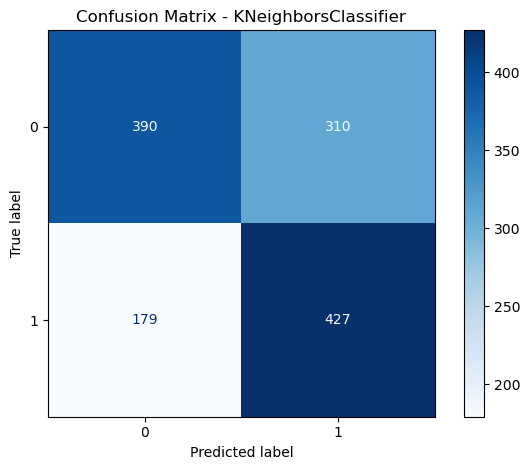

In [24]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from scipy.stats import randint



X = df_final.drop('Target', axis=1)
y = df_final['Target']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)


param_dist = {
    'n_neighbors': randint(1, 30),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}


knn = KNeighborsClassifier()


random_search = RandomizedSearchCV(
    estimator=knn,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)


random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

print("Best Parameters:", random_search.best_params_)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.title("Confusion Matrix - KNeighborsClassifier")
plt.tight_layout()
plt.show()

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.80      0.73       700
           1       0.71      0.55      0.62       606

    accuracy                           0.68      1306
   macro avg       0.69      0.68      0.67      1306
weighted avg       0.69      0.68      0.68      1306

Confusion Matrix:
 [[561 139]
 [273 333]]


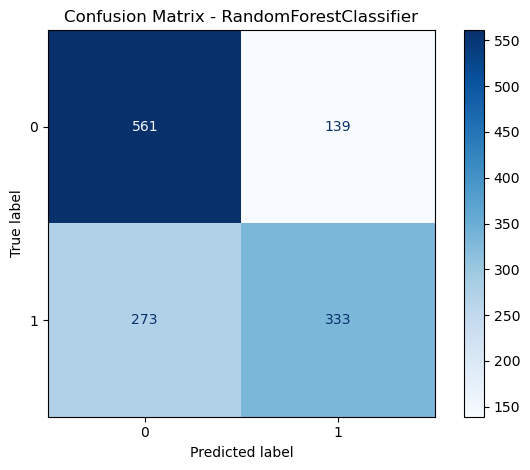

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix


X = df_final.drop('Target', axis=1)
y = df_final['Target']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)


model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    class_weight='balanced',
    random_state=42
)


model.fit(X_train, y_train)


y_pred = model.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.title("Confusion Matrix - RandomForestClassifier")
plt.tight_layout()
plt.show()

In [13]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X = df_final.drop('Target', axis=1)
y = df_final['Target']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.74      0.72       700
           1       0.68      0.63      0.65       606

    accuracy                           0.69      1306
   macro avg       0.69      0.69      0.69      1306
weighted avg       0.69      0.69      0.69      1306

XGBoost Confusion Matrix:
 [[519 181]
 [223 383]]


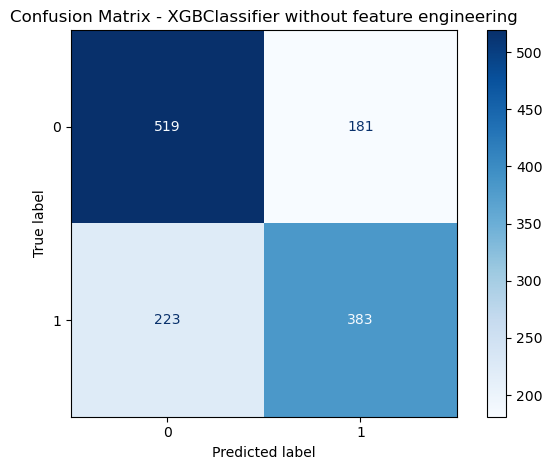

In [27]:
#without feature engineering

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix


xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)


xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)


print("XGBoost Classification Report:\n", classification_report(y_test, y_pred_xgb))
print("XGBoost Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
cm = confusion_matrix(y_test, y_pred_xgb)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.title("Confusion Matrix - XGBClassifier without feature engineering")
plt.tight_layout()
plt.show()

In [16]:
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

from sklearn.preprocessing import StandardScaler

models = {
    "Neural Network": MLPClassifier(max_iter=500, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
    "Naive Bayes": GaussianNB()
}

X = df_final.drop('Target', axis=1)
y = df_final['Target']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y)




results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Report': classification_report(y_test, y_pred, output_dict=True)
    })

df_results = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)
print(df_results[['Model', 'Accuracy']])

               Model  Accuracy
2           AdaBoost  0.712608
1  Gradient Boosting  0.698826
4        Naive Bayes  0.693721
0     Neural Network  0.689638
3        Extra Trees  0.663093


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters for Decision Tree: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 12, 'min_samples_split': 7}
Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.52      0.58       700
           1       0.55      0.69      0.61       606

    accuracy                           0.60      1306
   macro avg       0.60      0.60      0.59      1306
weighted avg       0.61      0.60      0.59      1306

Confusion Matrix:
 [[361 339]
 [189 417]]


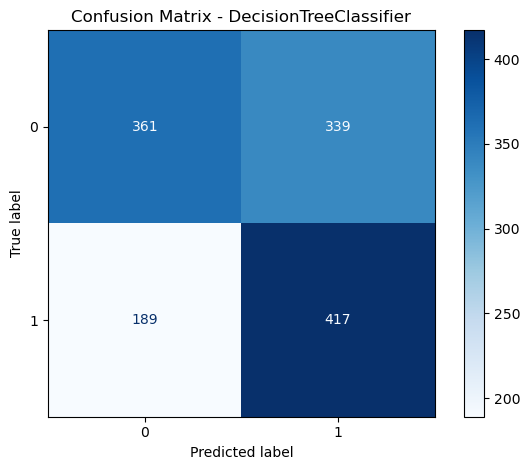

In [28]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from scipy.stats import randint



X = df_final.drop('Target', axis=1)
y = df_final['Target']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)


dt_base = DecisionTreeClassifier(random_state=42)


param_dist = {
    'max_depth': randint(3, 20),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 20),
    'criterion': ['gini', 'entropy']
}


random_search = RandomizedSearchCV(
    estimator=dt_base,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)


random_search.fit(X_train, y_train)
best_tree = random_search.best_estimator_
y_pred_tree = best_tree.predict(X_test)

print("Best Parameters for Decision Tree:", random_search.best_params_)
print("Classification Report:\n", classification_report(y_test, y_pred_tree))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tree))
cm = confusion_matrix(y_test, y_pred_tree)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.title("Confusion Matrix - DecisionTreeClassifier")
plt.tight_layout()
plt.show()

Number of PCA components retained: 18
Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.71      0.68       700
           1       0.63      0.57      0.60       606

    accuracy                           0.64      1306
   macro avg       0.64      0.64      0.64      1306
weighted avg       0.64      0.64      0.64      1306

Confusion Matrix:
 [[494 206]
 [259 347]]


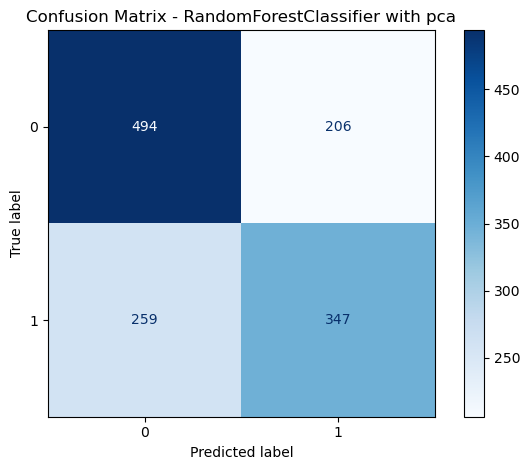

In [31]:
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix


X = df_final.drop('Target', axis=1)
y = df_final['Target']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)
print(f"Number of PCA components retained: {pca.n_components_}")


X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)


model = RandomForestClassifier(
    n_estimators=500,
    min_samples_split=2,
    min_samples_leaf=4,
    max_features='sqrt',
    max_depth=20,
    class_weight='balanced',
    bootstrap=True,
    random_state=42
)


model.fit(X_train, y_train)
y_pred = model.predict(X_test)


print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.title("Confusion Matrix - RandomForestClassifier with pca")
plt.tight_layout()
plt.show()


Classification Report: 
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       700
           1       0.86      0.75      0.80       606

    accuracy                           0.83      1306
   macro avg       0.83      0.82      0.82      1306
weighted avg       0.83      0.83      0.83      1306



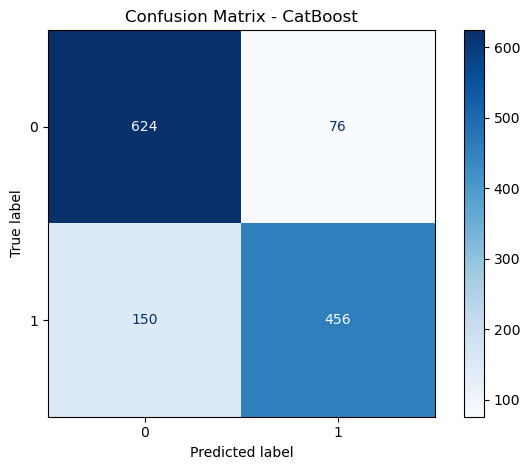

In [18]:
from collections import Counter
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


CAT_boost_selected_features = [
    "Pus cells in urine", "Age of the patient", "Body Mass Index (BMI)",
    "Sodium level (mEq/L)", "Estimated Glomerular Filtration Rate (eGFR)",
    "Urine protein-to-creatinine ratio", "Duration of diabetes mellitus (years)",
    "C-reactive protein (CRP) level", "Sugar in urine", "Cystatin C level",
    "Interleukin-6 (IL-6) level", "White blood cell count (cells/cumm)",
    "Cholesterol level", "Serum phosphate level", "Serum albumin level",
    "Family history of chronic kidney disease", "Bacteria in urine", "Appetite (good/poor)"
]

TARGET_COLUMN = "Target"


df_fe = df_main.copy()


df_fe["IL6_albumin_ratio"] = df_fe["Interleukin-6 (IL-6) level"] / df_fe["Serum albumin level"]
df_fe["protein_eGFR_ratio"] = df_fe["Urine protein-to-creatinine ratio"] / df_fe["Estimated Glomerular Filtration Rate (eGFR)"]
df_fe["CRP_WBC_ratio"] = df_fe["C-reactive protein (CRP) level"] / df_fe["White blood cell count (cells/cumm)"]


df_fe["log_Cystatin_C"] = np.log1p(df_fe["Cystatin C level"])
df_fe["sqrt_Cholesterol"] = np.sqrt(df_fe["Cholesterol level"])


df_fe["Age_group"] = pd.cut(df_fe["Age of the patient"], bins=[0, 30, 50, 70, 100], labels=["<30", "30-50", "50-70", "70+"])
df_fe["BMI_category"] = pd.cut(df_fe["Body Mass Index (BMI)"], bins=[0, 18.5, 25, 30, np.inf], labels=["Underweight", "Normal", "Overweight", "Obese"])


appetite_counts = df_fe["Appetite (good/poor)"].value_counts()
df_fe["Appetite_encoded"] = df_fe["Appetite (good/poor)"].map(appetite_counts)


for col in CAT_boost_selected_features:
    df_fe[col + "_missing_flag"] = df_fe[col].isnull().astype(int)


categorical_cols = [
    "Age_group", "BMI_category", "Appetite (good/poor)",
    "Family history of chronic kidney disease", "Pus cells in urine",
    "Sugar in urine", "Bacteria in urine"
]


X = df_fe.drop(columns=[TARGET_COLUMN])
y = df_fe[TARGET_COLUMN]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


class_counts = Counter(y_train)
total = sum(class_counts.values())
weights = {cls: total / count for cls, count in class_counts.items()}


model = CatBoostClassifier(
    verbose=False,
    scale_pos_weight=1.2,
    iterations=1000,
    depth=6,
    learning_rate=0.03,
    l2_leaf_reg=4,
    random_strength=1,
    bagging_temperature=0.5,
    border_count=128,
    early_stopping_rounds=100
)


model.fit(
    X_train, y_train,
    cat_features=categorical_cols,
    eval_set=(X_test, y_test)
)


preds = model.predict(X_test)
print("\nClassification Report: ")
print(classification_report(y_test, preds))

cm = confusion_matrix(y_test, preds)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.title("Confusion Matrix - CatBoost")
plt.tight_layout()
plt.show()



Classification Report: 
              precision    recall  f1-score   support

           0       0.80      0.90      0.85       700
           1       0.86      0.74      0.80       606

    accuracy                           0.82      1306
   macro avg       0.83      0.82      0.82      1306
weighted avg       0.83      0.82      0.82      1306



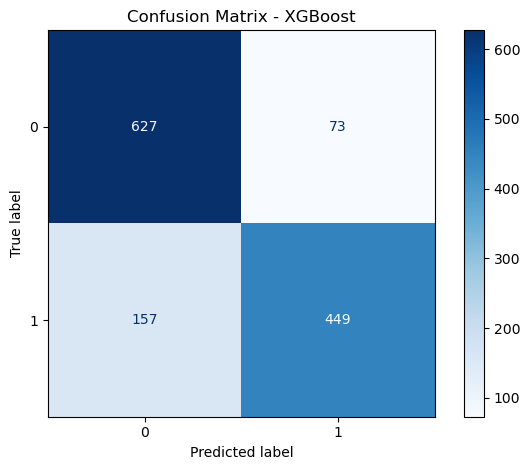

In [34]:
from collections import Counter
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


CAT_boost_selected_features = [
    "Pus cells in urine", "Age of the patient", "Body Mass Index (BMI)",
    "Sodium level (mEq/L)", "Estimated Glomerular Filtration Rate (eGFR)",
    "Urine protein-to-creatinine ratio", "Duration of diabetes mellitus (years)",
    "C-reactive protein (CRP) level", "Sugar in urine", "Cystatin C level",
    "Interleukin-6 (IL-6) level", "White blood cell count (cells/cumm)",
    "Cholesterol level", "Serum phosphate level", "Serum albumin level",
    "Family history of chronic kidney disease", "Bacteria in urine", "Appetite (good/poor)"
]

TARGET_COLUMN = "Target"


df_fe = df_main.copy()


df_fe["IL6_albumin_ratio"] = df_fe["Interleukin-6 (IL-6) level"] / df_fe["Serum albumin level"]
df_fe["protein_eGFR_ratio"] = df_fe["Urine protein-to-creatinine ratio"] / df_fe["Estimated Glomerular Filtration Rate (eGFR)"]
df_fe["CRP_WBC_ratio"] = df_fe["C-reactive protein (CRP) level"] / df_fe["White blood cell count (cells/cumm)"]


df_fe["log_Cystatin_C"] = np.log1p(df_fe["Cystatin C level"])
df_fe["sqrt_Cholesterol"] = np.sqrt(df_fe["Cholesterol level"])


df_fe["IL6_CRP_interaction"] = df_fe["Interleukin-6 (IL-6) level"] * df_fe["C-reactive protein (CRP) level"]
df_fe["BMI_sodium_interaction"] = df_fe["Body Mass Index (BMI)"] * df_fe["Sodium level (mEq/L)"]
df_fe["BMI_squared"] = df_fe["Body Mass Index (BMI)"] ** 2
df_fe["eGFR_squared"] = df_fe["Estimated Glomerular Filtration Rate (eGFR)"] ** 2


df_fe["Age_group"] = pd.cut(df_fe["Age of the patient"], bins=[0, 30, 50, 70, 100], labels=["<30", "30-50", "50-70", "70+"])
df_fe["BMI_category"] = pd.cut(df_fe["Body Mass Index (BMI)"], bins=[0, 18.5, 25, 30, np.inf], labels=["Underweight", "Normal", "Overweight", "Obese"])


appetite_counts = df_fe["Appetite (good/poor)"].value_counts()
df_fe["Appetite_encoded"] = df_fe["Appetite (good/poor)"].map(appetite_counts)


for col in CAT_boost_selected_features:
    df_fe[col + "_missing_flag"] = df_fe[col].isnull().astype(int)


categorical_cols = [
    "Age_group", "BMI_category", "Appetite (good/poor)",
    "Family history of chronic kidney disease", "Pus cells in urine",
    "Sugar in urine", "Bacteria in urine"
]

for col in categorical_cols:
    df_fe[col] = df_fe[col].astype(str).fillna("missing")
    le = LabelEncoder()
    df_fe[col] = le.fit_transform(df_fe[col])


X = df_fe.drop(columns=[TARGET_COLUMN])
y = df_fe[TARGET_COLUMN]


class_counts = Counter(y)
total = sum(class_counts.values())
weights = {cls: total / count for cls, count in class_counts.items()}
scale_pos_weight = weights[0] / weights[1] if 0 in weights and 1 in weights else 1


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


xgb_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=4,
    random_state=42
)

xgb_model.fit(X_train, y_train)


preds = xgb_model.predict(X_test)
print("\nClassification Report: ")
print(classification_report(y_test, preds))

cm = confusion_matrix(y_test, preds)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.title("Confusion Matrix - XGBoost")
plt.tight_layout()
plt.show()



 Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.68      0.66      0.67       700
           1       0.62      0.65      0.64       606

    accuracy                           0.65      1306
   macro avg       0.65      0.65      0.65      1306
weighted avg       0.66      0.65      0.65      1306



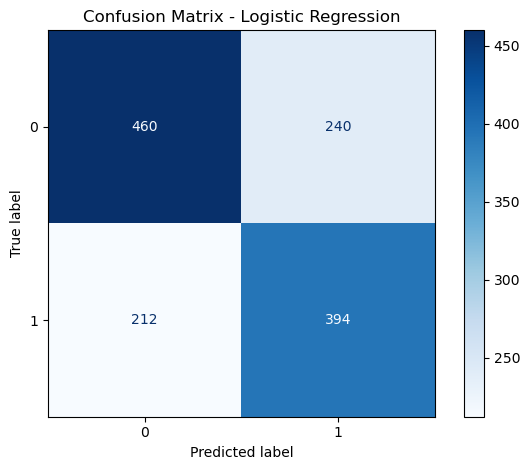


 Model: SVM
              precision    recall  f1-score   support

           0       0.77      0.86      0.81       700
           1       0.81      0.71      0.76       606

    accuracy                           0.79      1306
   macro avg       0.79      0.78      0.79      1306
weighted avg       0.79      0.79      0.79      1306



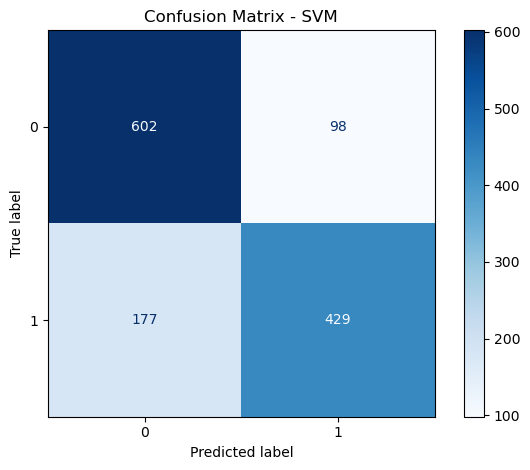


 Model: KNN
              precision    recall  f1-score   support

           0       0.64      0.29      0.39       700
           1       0.50      0.81      0.62       606

    accuracy                           0.53      1306
   macro avg       0.57      0.55      0.51      1306
weighted avg       0.57      0.53      0.50      1306



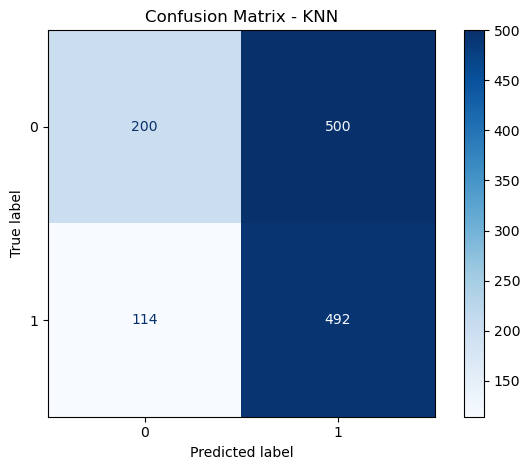


 Model: Random Forest
              precision    recall  f1-score   support

           0       0.71      0.88      0.78       700
           1       0.80      0.59      0.68       606

    accuracy                           0.74      1306
   macro avg       0.76      0.73      0.73      1306
weighted avg       0.75      0.74      0.74      1306



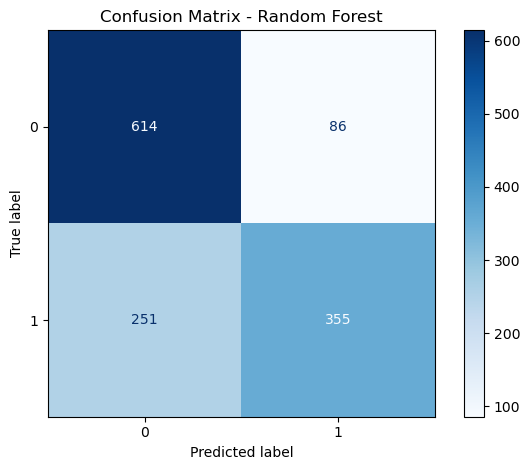


 Model: Decision Tree
              precision    recall  f1-score   support

           0       0.63      0.63      0.63       700
           1       0.58      0.58      0.58       606

    accuracy                           0.61      1306
   macro avg       0.60      0.60      0.60      1306
weighted avg       0.61      0.61      0.61      1306



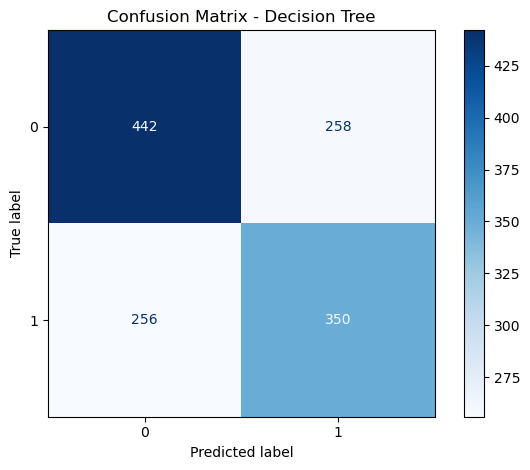


 Model: Gradient Boosting
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       700
           1       0.77      0.69      0.73       606

    accuracy                           0.76      1306
   macro avg       0.76      0.75      0.76      1306
weighted avg       0.76      0.76      0.76      1306



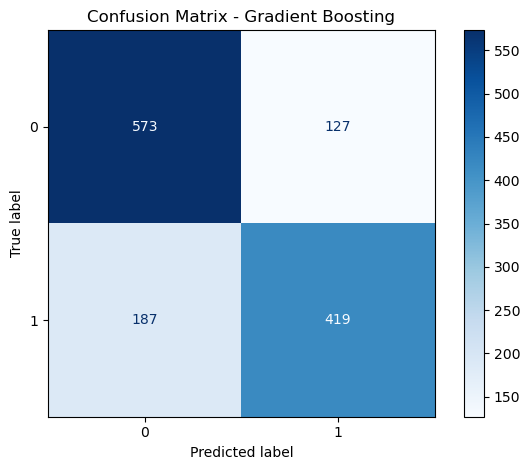


 Model: AdaBoost
              precision    recall  f1-score   support

           0       0.77      0.81      0.79       700
           1       0.77      0.73      0.75       606

    accuracy                           0.77      1306
   macro avg       0.77      0.77      0.77      1306
weighted avg       0.77      0.77      0.77      1306



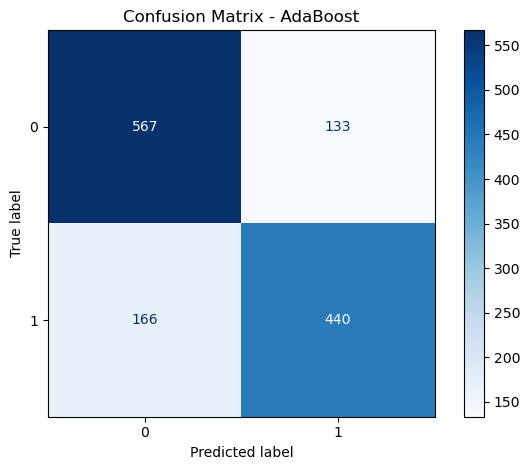


 Model: Naive Bayes
              precision    recall  f1-score   support

           0       0.75      0.74      0.75       700
           1       0.71      0.72      0.71       606

    accuracy                           0.73      1306
   macro avg       0.73      0.73      0.73      1306
weighted avg       0.73      0.73      0.73      1306



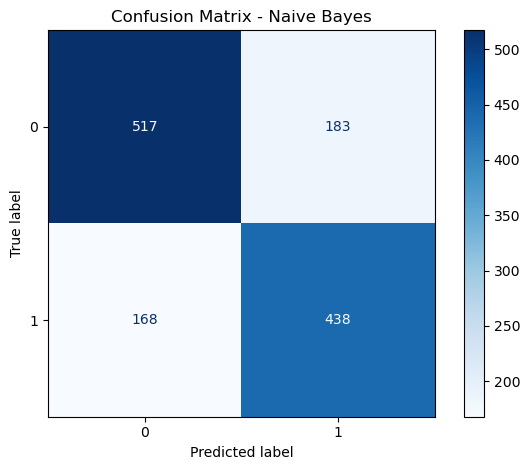


 Model: MLP (ANN)
              precision    recall  f1-score   support

           0       0.73      0.65      0.68       700
           1       0.64      0.72      0.68       606

    accuracy                           0.68      1306
   macro avg       0.68      0.68      0.68      1306
weighted avg       0.69      0.68      0.68      1306



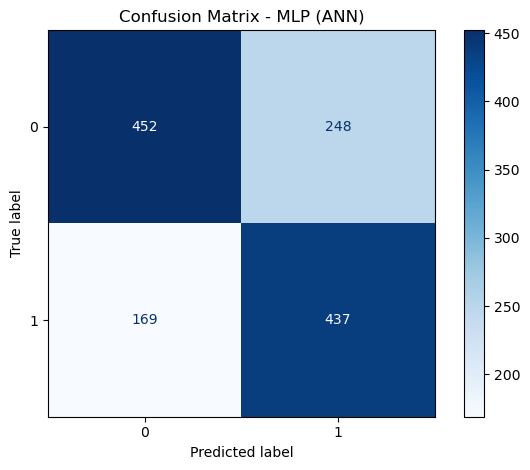

In [35]:

from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
)
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier


CAT_boost_selected_features = [
    "Pus cells in urine", "Age of the patient", "Body Mass Index (BMI)",
    "Sodium level (mEq/L)", "Estimated Glomerular Filtration Rate (eGFR)",
    "Urine protein-to-creatinine ratio", "Duration of diabetes mellitus (years)",
    "C-reactive protein (CRP) level", "Sugar in urine", "Cystatin C level",
    "Interleukin-6 (IL-6) level", "White blood cell count (cells/cumm)",
    "Cholesterol level", "Serum phosphate level", "Serum albumin level",
    "Family history of chronic kidney disease", "Bacteria in urine", "Appetite (good/poor)"
]

TARGET_COLUMN = "Target"


df_fe = df_main.copy()

df_fe["IL6_albumin_ratio"] = df_fe["Interleukin-6 (IL-6) level"] / df_fe["Serum albumin level"]
df_fe["protein_eGFR_ratio"] = df_fe["Urine protein-to-creatinine ratio"] / df_fe["Estimated Glomerular Filtration Rate (eGFR)"]
df_fe["CRP_WBC_ratio"] = df_fe["C-reactive protein (CRP) level"] / df_fe["White blood cell count (cells/cumm)"]
df_fe["log_Cystatin_C"] = np.log1p(df_fe["Cystatin C level"])
df_fe["sqrt_Cholesterol"] = np.sqrt(df_fe["Cholesterol level"])
df_fe["IL6_CRP_interaction"] = df_fe["Interleukin-6 (IL-6) level"] * df_fe["C-reactive protein (CRP) level"]
df_fe["BMI_sodium_interaction"] = df_fe["Body Mass Index (BMI)"] * df_fe["Sodium level (mEq/L)"]
df_fe["BMI_squared"] = df_fe["Body Mass Index (BMI)"] ** 2
df_fe["eGFR_squared"] = df_fe["Estimated Glomerular Filtration Rate (eGFR)"] ** 2
df_fe["Age_group"] = pd.cut(df_fe["Age of the patient"], bins=[0, 30, 50, 70, 100], labels=["<30", "30-50", "50-70", "70+"])
df_fe["BMI_category"] = pd.cut(df_fe["Body Mass Index (BMI)"], bins=[0, 18.5, 25, 30, np.inf], labels=["Underweight", "Normal", "Overweight", "Obese"])

appetite_counts = df_fe["Appetite (good/poor)"].value_counts()
df_fe["Appetite_encoded"] = df_fe["Appetite (good/poor)"].map(appetite_counts)

for col in CAT_boost_selected_features:
    df_fe[col + "_missing_flag"] = df_fe[col].isnull().astype(int)


categorical_cols = [
    "Age_group", "BMI_category", "Appetite (good/poor)",
    "Family history of chronic kidney disease", "Pus cells in urine",
    "Sugar in urine", "Bacteria in urine"
]

for col in categorical_cols:
    df_fe[col] = df_fe[col].astype(str).fillna("missing")
    le = LabelEncoder()
    df_fe[col] = le.fit_transform(df_fe[col])


X = df_fe.drop(columns=[TARGET_COLUMN])
y = df_fe[TARGET_COLUMN]


scaler = MinMaxScaler()
X[X.columns] = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "SVM": SVC(probability=True, class_weight='balanced'),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced'),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Naive Bayes": GaussianNB(),
    "MLP (ANN)": MLPClassifier(hidden_layer_sizes=(100,), max_iter=500)
}


for name, model in models.items():
    print(f"\n Model: {name}")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    print(classification_report(y_test, preds))

    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.show()



Optimal Threshold for Class 1 Recall: 0.46
Class 1 Recall: 0.77

-Final Classification Report : 
              precision    recall  f1-score   support

           0       0.81      0.83      0.82       700
           1       0.80      0.77      0.78       606

    accuracy                           0.80      1306
   macro avg       0.80      0.80      0.80      1306
weighted avg       0.80      0.80      0.80      1306



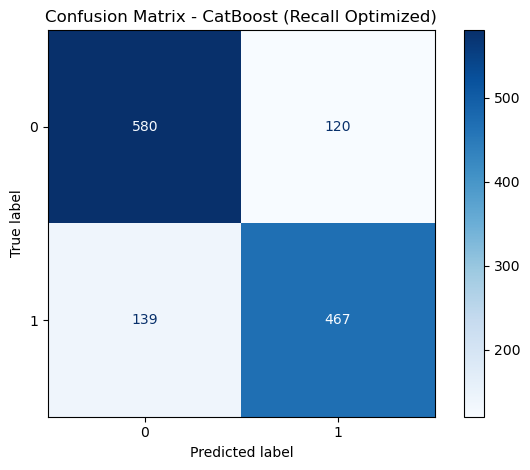

In [36]:
from collections import Counter
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve
)
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE


CAT_boost_selected_features = [
    "Pus cells in urine", "Age of the patient", "Body Mass Index (BMI)",
    "Sodium level (mEq/L)", "Estimated Glomerular Filtration Rate (eGFR)",
    "Urine protein-to-creatinine ratio", "Duration of diabetes mellitus (years)",
    "C-reactive protein (CRP) level", "Sugar in urine", "Cystatin C level",
    "Interleukin-6 (IL-6) level", "White blood cell count (cells/cumm)",
    "Cholesterol level", "Serum phosphate level", "Serum albumin level",
    "Family history of chronic kidney disease", "Bacteria in urine", "Appetite (good/poor)"
]

TARGET_COLUMN = "Target"


df_fe = df_main.copy()
df_fe["IL6_albumin_ratio"] = df_fe["Interleukin-6 (IL-6) level"] / df_fe["Serum albumin level"]
df_fe["protein_eGFR_ratio"] = df_fe["Urine protein-to-creatinine ratio"] / df_fe["Estimated Glomerular Filtration Rate (eGFR)"]
df_fe["CRP_WBC_ratio"] = df_fe["C-reactive protein (CRP) level"] / df_fe["White blood cell count (cells/cumm)"]
df_fe["log_Cystatin_C"] = np.log1p(df_fe["Cystatin C level"])
df_fe["sqrt_Cholesterol"] = np.sqrt(df_fe["Cholesterol level"])
df_fe["Age_group"] = pd.cut(df_fe["Age of the patient"], bins=[0, 30, 50, 70, 100],
                            labels=["<30", "30-50", "50-70", "70+"])
df_fe["BMI_category"] = pd.cut(df_fe["Body Mass Index (BMI)"], bins=[0,18.5,25,30,np.inf],
                               labels=["Underweight", "Normal", "Overweight", "Obese"])
appetite_counts = df_fe["Appetite (good/poor)"].value_counts()
df_fe["Appetite_encoded"] = df_fe["Appetite (good/poor)"].map(appetite_counts)

for col in CAT_boost_selected_features:
    df_fe[col + "_missing_flag"] = df_fe[col].isnull().astype(int)


categorical_cols = [
    "Age_group", "BMI_category", "Appetite (good/poor)",
    "Family history of chronic kidney disease", "Pus cells in urine",
    "Sugar in urine", "Bacteria in urine"
]


for col in categorical_cols:
    le = LabelEncoder()
    df_fe[col] = le.fit_transform(df_fe[col].astype(str).fillna("missing"))


X = df_fe.drop(columns=[TARGET_COLUMN])
y = df_fe[TARGET_COLUMN]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)


model = CatBoostClassifier(
    verbose=False,
    iterations=1000,
    depth=6,
    learning_rate=0.03,
    l2_leaf_reg=4,
    random_strength=1,
    bagging_temperature=0.5,
    border_count=128,
    early_stopping_rounds=100
)

model.fit(
    X_train_res, y_train_res,
    cat_features=categorical_cols,
    eval_set=(X_test, y_test)
)


probs = model.predict_proba(X_test)


best_recall = 0
best_threshold = 0.5

for t in np.linspace(0.2, 0.6, 100):
    preds = (probs[:, 1] >= t).astype(int)
    report = classification_report(y_test, preds, output_dict=True)
    recall_class_1 = report['1']['recall']
    accuracy = report['accuracy']
    
    if recall_class_1 > best_recall and accuracy >= 0.80:
        best_recall = recall_class_1
        best_threshold = t


final_preds = (probs[:, 1] >= best_threshold).astype(int)

print(f"\nOptimal Threshold for Class 1 Recall: {best_threshold:.2f}")
print(f"Class 1 Recall: {best_recall:.2f}\n")
print("-Final Classification Report : ")
print(classification_report(y_test, final_preds))

cm = confusion_matrix(y_test, final_preds)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.title("Confusion Matrix - CatBoost (Recall Optimized)")
plt.tight_layout()
plt.show()
